# Building the Dataset

The first notebook showed that the four source files can be joined safely and identified the exact rules needed to create the final cohort. This notebook now applies those rules.

The goal is to turn the raw NHANES components into one table where:

- each row represents one participant,
- `has_cavity` records whether that participant has at least one untreated cavity, and
- each remaining column is a predictor that can be used by the later modeling notebooks.

This is the only notebook that changes the structure of the raw data. Every exclusion and transformation is shown directly rather than treating the final spreadsheet like a black box.

## Construction Plan

The dataset will be built in six steps:

1. Keep participants with a complete dental examination.
2. Define the cavity target from the 28 tooth-condition fields.
3. Merge the demographic, oral-health, and diabetes predictors using `SEQN`.
4. Remove the small number of unusable questionnaire responses.
5. Convert the remaining variables into model-ready numeric columns.
6. Export the final table as `cavity_training_data.csv`.

Income is the one exception to the usual cleaning process. Its missing values will be preserved so that imputation can happen later using training data only.

## Imports and Setup

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
# Keeping the plots visually consistent with the first notebook and CMOR repository.
sns.set_theme(style="whitegrid")
PURPLE = "#5d32ca"
GREEN = "#82b600"
BLUE = "#2196f3"
GRAY = "#6b7280"

# Locate the project root
# This works whether Jupyter starts in the repository root or notebooks folder.
current_directory = Path.cwd().resolve()
if (current_directory / "data" / "raw").exists():
    PROJECT_ROOT = current_directory
elif current_directory.name == "notebooks" and (current_directory.parent / "data" / "raw").exists():
    PROJECT_ROOT = current_directory.parent
else:
    raise FileNotFoundError(
        "Could not locate data/raw. Open this notebook from inside the project repository."
    )

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_FILE = PROCESSED_DIR / "cavity_training_data.csv"

# Map each required NHANES component to its raw file path.
SOURCE_FILES = {
    "Dental examination": RAW_DIR / "P_OHXDEN.xpt",
    "Demographics": RAW_DIR / "P_DEMO.xpt",
    "Oral-health questionnaire": RAW_DIR / "P_OHQ.xpt",
    "Diabetes questionnaire": RAW_DIR / "P_DIQ.xpt",
}

# Stop immediately if any source file is unavailable.
missing_files = [path.name for path in SOURCE_FILES.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing required raw files: {missing_files}")

print("Project root located successfully.")
print("All four raw NHANES files were found.")
print("Final output: data/processed/cavity_training_data.csv")

Project root located successfully.
All four raw NHANES files were found.
Final output: data/processed/cavity_training_data.csv


## Loading the Raw Components

In [2]:
# Load each XPT file without changing the original source data.
datasets = {
    name: pd.read_sas(path, format="xport", encoding="utf-8")
    for name, path in SOURCE_FILES.items()
}

# Give each DataFrame a short name for the construction steps below.
dental = datasets["Dental examination"]
demo = datasets["Demographics"]
oral_health = datasets["Oral-health questionnaire"]
diabetes = datasets["Diabetes questionnaire"]

# Confirm that each source still has one unique row per participant.
source_summary = pd.DataFrame(
    [
        {
            "Component": name,
            "Rows": len(frame),
            "Unique SEQN": frame["SEQN"].nunique(),
            "Duplicate SEQN": frame["SEQN"].duplicated().sum(),
        }
        for name, frame in datasets.items()
    ]
)

assert source_summary["Duplicate SEQN"].sum() == 0
source_summary

,Component,Rows,Unique SEQN,Duplicate SEQN
0,Dental examination,13772,13772,0
1,Demographics,15560,15560,0
2,Oral-health questionnaire,14986,14986,0
3,Diabetes questionnaire,14986,14986,0


The raw files are loaded again rather than importing a table from Notebook 1. This keeps Notebook 2 reproducible on its own: anyone with the four original NHANES files can rerun the construction process from the beginning.

## Step 1: Keeping Complete Dental Examinations

In [4]:
# OHDEXSTS = 1 means the participant received a complete dental examination.
# Partial and uncompleted exams cannot reliably establish that a person is cavity-free.
complete_dental = dental.loc[dental["OHDEXSTS"].eq(1)].copy()

exam_filter_summary = pd.DataFrame(
    {
        "Stage": [
            "Participants in the raw dental file",
            "Participants with a complete examination",
            "Partial or uncompleted examinations removed",
        ],
        "Participants": [
            len(dental),
            len(complete_dental),
            len(dental) - len(complete_dental),
        ],
    }
)

# Checking its accurate with how many participants have a complete dental examination.
# re-run of this notebook (e.g. on updated raw data) produces a different count.
assert len(complete_dental) == 13_271
exam_filter_summary

,Stage,Participants
0,Participants in the raw dental file,13772
1,Participants with a complete examination,13271
2,Partial or uncompleted examinations removed,501


This first rule removes 501 people: seven had partial examinations and 494 were not examined. They are excluded before the target is constructed, so nobody is labeled as cavity-free merely because their tooth information is incomplete.

## Step 2: Defining the Cavity Target

NHANES records the condition of each examined tooth in an `OHX##CTC` field. The two codes that represent untreated caries are:

- `K` for an untreated cavity in a primary tooth
- `Z` for an untreated cavity in a permanent tooth

The prediction target is therefore:

$$
\text{has\_cavity} =
\begin{cases}
1, & \text{if at least one tooth contains K or Z} \\
0, & \text{otherwise}
\end{cases}
$$

This definition counts untreated cavities only. A filled tooth is not treated as a current cavity.

In [6]:
# Find the 28 tooth-condition fields using their shared naming pattern.
tooth_condition_columns = [
    column for column in complete_dental.columns
    if re.fullmatch(r"OHX\d{2}CTC", column)
]

# Standardize the tooth codes before checking for K or Z.
tooth_codes = (
    complete_dental[tooth_condition_columns]
    .astype("string")
    .apply(lambda column: column.str.strip().str.upper())
)

# A participant is positive if any examined tooth has untreated caries.
target_table = complete_dental[["SEQN"]].copy()
target_table["has_cavity"] = tooth_codes.isin(["K", "Z"]).any(axis=1).astype(int)

# Summarize the target before adding any predictors.
target_summary = (
    target_table["has_cavity"]
    .value_counts()
    .sort_index()
    .rename(index={0: "No untreated cavity", 1: "At least one untreated cavity"})
    .rename_axis("Cavity status")
    .reset_index(name="Participants")
)
target_summary["Percent"] = target_summary["Participants"] / len(target_table) * 100

assert len(tooth_condition_columns) == 28
assert target_table["has_cavity"].sum() == 2_435
target_summary

,Cavity status,Participants,Percent
0,No untreated cavity,10836,81.651722
1,At least one untreated cavity,2435,18.348278


At this stage, 2,435 of the 13,271 completely examined participants have at least one untreated cavity. Some of these participants will be removed in Step 4 because their predictor responses are unusable, which is why this count is slightly larger than the final 2,420 cases.

## Step 3: Merging the Predictor Fields

Only the fields needed for the model are selected before merging. This keeps the construction process easy to audit and prevents unrelated NHANES variables from entering the dataset accidentally.

The target table is used as the starting point, and each source is joined through `SEQN`. The `validate="one_to_one"` argument forces pandas to stop if a source ever contains duplicated participant IDs.

In [7]:
# Select the raw fields needed from each component.
demographic_fields = ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH3", "INDFMPIR"]
oral_health_fields = ["SEQN", "OHQ030", "OHQ845"]
diabetes_fields = ["SEQN", "DIQ010"]

# Merge all predictor sources onto the completed-exam target table.
merged = (
    target_table
    .merge(
        demo[demographic_fields],
        on="SEQN", how="left", validate="one_to_one"
    )
    .merge(
        oral_health[oral_health_fields],
        on="SEQN", how="left", validate="one_to_one"
    )
    .merge(
        diabetes[diabetes_fields],
        on="SEQN", how="left", validate="one_to_one"
    )
)

# Confirm that the joins neither lost participants nor multiplied rows.
merge_summary = pd.DataFrame(
    {
        "Check": [
            "Rows before merging predictors",
            "Rows after merging predictors",
            "Unique SEQN after merging",
            "Duplicate SEQN after merging",
        ],
        "Result": [
            len(target_table),
            len(merged),
            merged["SEQN"].nunique(),
            merged["SEQN"].duplicated().sum(),
        ],
    }
)

assert len(merged) == len(target_table)
assert merged["SEQN"].is_unique
merge_summary

,Check,Result
0,Rows before merging predictors,13271
1,Rows after merging predictors,13271
2,Unique SEQN after merging,13271
3,Duplicate SEQN after merging,0


The merged table still contains exactly 13,271 unique people. That confirms the four files joined as expected and no participant received extra weight through duplicated rows.

## Step 4: Removing Unusable Responses

The first notebook identified three predictors with only a few unusable responses:

- `OHQ030` must be between 1 and 7.
- `OHQ845` must be between 1 and 5.
- `DIQ010` must be 1, 2, or 3.

Codes such as *don't know* are removed rather than treated as real values. Income is not part of this filter because its missing values are intentionally retained.

In [8]:
# Identify whether each required questionnaire response is usable.
valid_dental_visit = merged["OHQ030"].isin(range(1, 8))
valid_teeth_condition = merged["OHQ845"].isin(range(1, 6))
valid_diabetes = merged["DIQ010"].isin([1, 2, 3])

# Count each issue separately and then count the unique rows affected.
valid_predictors = valid_dental_visit & valid_teeth_condition & valid_diabetes

exclusion_summary = pd.DataFrame(
    {
        "Reason": [
            "Invalid or missing dental-visit response",
            "Invalid or missing teeth-condition response",
            "Invalid or unknown diabetes response",
            "Unique participants removed",
        ],
        "Participants": [
            (~valid_dental_visit).sum(),
            (~valid_teeth_condition).sum(),
            (~valid_diabetes).sum(),
            (~valid_predictors).sum(),
        ],
    }
)

# Apply all three exclusion rules at the same time.
cleaned = merged.loc[valid_predictors].copy()

assert (~valid_predictors).sum() == 56
assert len(cleaned) == 13_215
exclusion_summary

,Reason,Participants
0,Invalid or missing dental-visit response,39
1,Invalid or missing teeth-condition response,12
2,Invalid or unknown diabetes response,8
3,Unique participants removed,56


The individual problem counts add to more than 56 because a few participants are missing more than one response. Applying the filters together removes **56 unique participants**, leaving the planned cohort of **13,215**.

## Step 5: Creating the Model-Ready Columns

The remaining variables are converted into clearly named numeric features:

| Raw field | Model-ready representation |
|---|---|
| `RIDAGEYR` | Age in years |
| `RIAGENDR` | `sex_female`, with male as the reference |
| `RIDRETH3` | Five binary columns, with non-Hispanic White as the reference |
| `INDFMPIR` | Income-to-poverty ratio plus a missingness flag |
| `OHQ030` | Ordered dental-visit recency from 1 to 7 |
| `OHQ845` | Ordered self-rated teeth condition from 1 to 5 |
| `DIQ010` | Separate diabetes and borderline-diabetes indicators |

A reference category is represented when every indicator in its group equals zero. This avoids redundant columns while still preserving the full category information.

In [9]:
# Start the final table with the participant ID and prediction target.
cavity_training_data = cleaned[["SEQN", "has_cavity"]].copy()

# Rename and preserve the two continuous predictors.
cavity_training_data["age"] = cleaned["RIDAGEYR"].astype(int)
cavity_training_data["income_poverty_ratio"] = cleaned["INDFMPIR"]

# Convert sex and diabetes responses into binary indicator columns.
cavity_training_data["sex_female"] = cleaned["RIAGENDR"].eq(2).astype(int)
cavity_training_data["diabetes_yes"] = cleaned["DIQ010"].eq(1).astype(int)
cavity_training_data["diabetes_borderline"] = cleaned["DIQ010"].eq(3).astype(int)

# Keep the natural order of the two questionnaire responses.
# Higher values represent less recent dental care or worse self-rated condition.
cavity_training_data["dental_visit_recency_ord"] = cleaned["OHQ030"].astype(int)
cavity_training_data["teeth_condition_ord"] = cleaned["OHQ845"].astype(int)

# One-hot encode race/ethnicity while leaving non-Hispanic White as the reference.
race_columns = {
    "race_mexican_american": 1,
    "race_other_hispanic": 2,
    "race_non-hispanic_black": 4,
    "race_non-hispanic_asian": 6,
    "race_other_multi": 7,
}

for column_name, nhanes_code in race_columns.items():
    cavity_training_data[column_name] = cleaned["RIDRETH3"].eq(nhanes_code).astype(int)

# Preserve missing income and record where it occurs.
# The actual values will be imputed inside the later training pipeline.
cavity_training_data["income_poverty_ratio_missing"] = (
    cavity_training_data["income_poverty_ratio"].isna().astype(int)
)

# Store participant IDs as integers rather than decimal values.
cavity_training_data["SEQN"] = cavity_training_data["SEQN"].astype(int)

cavity_training_data.head()

,SEQN,has_cavity,age,income_poverty_ratio,sex_female,diabetes_yes,diabetes_borderline,dental_visit_recency_ord,teeth_condition_ord,race_mexican_american,race_other_hispanic,race_non-hispanic_black,race_non-hispanic_asian,race_other_multi,income_poverty_ratio_missing
0,109263,0,2,4.66,0,0,0,7,1,0,0,0,1,0,0
1,109264,0,13,0.83,1,0,0,1,3,1,0,0,0,0,0
2,109265,0,2,3.06,0,0,0,1,4,0,0,0,0,0,0
3,109266,0,29,5.00,1,0,0,1,4,0,0,0,1,0,0
4,109269,0,2,0.96,0,0,0,1,3,0,1,0,0,0,0


The final table contains 15 columns: one identifier, one target, and 13 predictors or predictor indicators. `SEQN` is retained only for traceability and will be removed from the feature matrix before model training.

The missing-income flag allows the model to recognize that income was not reported without inventing a value at this stage. The missing income itself remains blank.

## Checking the Final Cohort

In [10]:
# Summarize the most important final checks in one table.
final_checks = pd.DataFrame(
    {
        "Check": [
            "Participants",
            "Columns",
            "Unique SEQN",
            "Duplicate SEQN",
            "Cavity cases",
            "Non-cavity cases",
            "Missing income values retained",
            "Missing values outside income",
        ],
        "Result": [
            len(cavity_training_data),
            cavity_training_data.shape[1],
            cavity_training_data["SEQN"].nunique(),
            cavity_training_data["SEQN"].duplicated().sum(),
            cavity_training_data["has_cavity"].sum(),
            cavity_training_data["has_cavity"].eq(0).sum(),
            cavity_training_data["income_poverty_ratio"].isna().sum(),
            cavity_training_data.drop(columns="income_poverty_ratio").isna().sum().sum(),
        ],
    }
)

# These assertions make the notebook fail loudly if any construction rule changes.
assert cavity_training_data.shape == (13_215, 15)
assert cavity_training_data["SEQN"].is_unique
assert cavity_training_data["has_cavity"].sum() == 2_420
assert cavity_training_data["has_cavity"].eq(0).sum() == 10_795
assert cavity_training_data["income_poverty_ratio"].isna().sum() == 1_684
assert cavity_training_data.drop(columns="income_poverty_ratio").isna().sum().sum() == 0
assert (
    cavity_training_data["income_poverty_ratio_missing"]
    .eq(cavity_training_data["income_poverty_ratio"].isna().astype(int))
    .all()
)

print("All final cohort checks passed.")
final_checks

All final cohort checks passed.


,Check,Result
0,Participants,13215
1,Columns,15
2,Unique SEQN,13215
3,Duplicate SEQN,0
4,Cavity cases,2420
5,Non-cavity cases,10795
6,Missing income values retained,1684
7,Missing values outside income,0


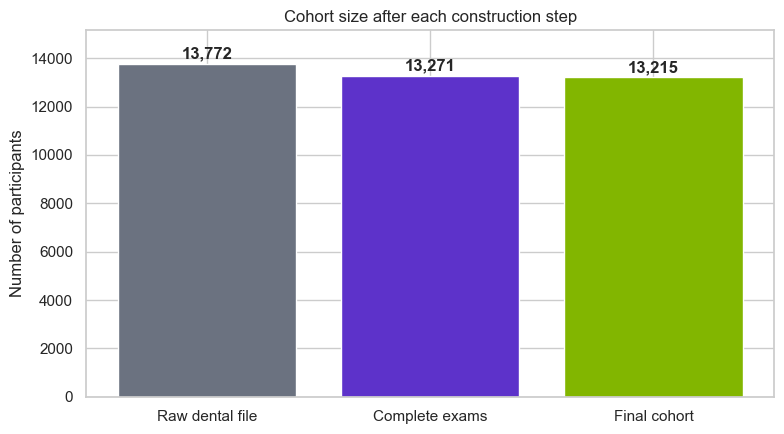

In [11]:
# Visualize where participants were removed during cohort construction.
cohort_flow = pd.DataFrame(
    {
        "Stage": [
            "Raw dental file",
            "Complete exams",
            "Final cohort",
        ],
        "Participants": [
            len(dental),
            len(complete_dental),
            len(cavity_training_data),
        ],
    }
)

plt.figure(figsize=(8, 4.5))
bars = plt.bar(
    cohort_flow["Stage"],
    cohort_flow["Participants"],
    color=[GRAY, PURPLE, GREEN],
)

for bar, value in zip(bars, cohort_flow["Participants"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 90,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.ylabel("Number of participants")
plt.title("Cohort size after each construction step")
plt.ylim(0, cohort_flow["Participants"].max() * 1.1)
plt.tight_layout()
plt.show()

The final cohort retains about 96% of the participants who completed the dental examination. Most exclusions occur because the examination was incomplete, not because of missing predictor data.

## Final Column Guide

In [12]:
# Create a compact data dictionary for the exported table.
column_guide = pd.DataFrame(
    [
        ("SEQN", "NHANES participant identifier", "Identifier only; not a model feature"),
        ("has_cavity", "At least one untreated cavity", "0 = no, 1 = yes"),
        ("age", "Age in years", "80 represents 80 or older"),
        ("income_poverty_ratio", "Family income-to-poverty ratio", "0–5; missing values retained"),
        ("sex_female", "Female sex indicator", "Male is the reference"),
        ("diabetes_yes", "Diagnosed diabetes indicator", "No diabetes is the reference"),
        ("diabetes_borderline", "Borderline diabetes indicator", "No diabetes is the reference"),
        ("dental_visit_recency_ord", "Time since last dental visit", "1–7; higher means less recent"),
        ("teeth_condition_ord", "Self-rated teeth and gum condition", "1–5; higher means worse"),
        ("race_mexican_american", "Mexican American indicator", "Non-Hispanic White is the reference"),
        ("race_other_hispanic", "Other Hispanic indicator", "Non-Hispanic White is the reference"),
        ("race_non-hispanic_black", "Non-Hispanic Black indicator", "Non-Hispanic White is the reference"),
        ("race_non-hispanic_asian", "Non-Hispanic Asian indicator", "Non-Hispanic White is the reference"),
        ("race_other_multi", "Other or multiracial indicator", "Non-Hispanic White is the reference"),
        ("income_poverty_ratio_missing", "Income response is missing", "0 = present, 1 = missing"),
    ],
    columns=["Column", "Meaning", "Coding note"],
)

column_guide

,Column,Meaning,Coding note
0,SEQN,NHANES participant identifier,Identifier only; not a model feature
1,has_cavity,At least one untreated cavity,"0 = no, 1 = yes"
2,age,Age in years,80 represents 80 or older
3,income_poverty_ratio,Family income-to-poverty ratio,0–5; missing values retained
4,sex_female,Female sex indicator,Male is the reference
5,diabetes_yes,Diagnosed diabetes indicator,No diabetes is the reference
6,diabetes_borderline,Borderline diabetes indicator,No diabetes is the reference
7,dental_visit_recency_ord,Time since last dental visit,1–7; higher means less recent
8,teeth_condition_ord,Self-rated teeth and gum condition,1–5; higher means worse
9,race_mexican_american,Mexican American indicator,Non-Hispanic White is the reference


## Exporting the Training Data

In [13]:
# Create the processed-data folder if it does not already exist.
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Export one plain numeric CSV without the pandas row index.
cavity_training_data.to_csv(OUTPUT_FILE, index=False)

print(f"Saved {len(cavity_training_data):,} rows and {cavity_training_data.shape[1]} columns.")
print("Output file: data/processed/cavity_training_data.csv")

Saved 13,215 rows and 15 columns.
Output file: data/processed/cavity_training_data.csv


The exported CSV is the single dataset used by the remaining notebooks. Those notebooks should read this file rather than rebuilding the cohort differently each time.

One final read-back check confirms that the saved file has the same dimensions, columns, target counts, and missing-income pattern as the table in memory.

In [15]:
# Reload the exported file to verify what was actually written to disk.
saved_data = pd.read_csv(OUTPUT_FILE)

assert saved_data.shape == cavity_training_data.shape
assert saved_data.columns.tolist() == cavity_training_data.columns.tolist()
assert saved_data["SEQN"].is_unique
assert saved_data["has_cavity"].sum() == 2_420
assert saved_data["income_poverty_ratio"].isna().sum() == 1_684

print("The exported CSV passed every read-back check.")
saved_data.head()

The exported CSV passed every read-back check.


,SEQN,has_cavity,age,income_poverty_ratio,sex_female,diabetes_yes,diabetes_borderline,dental_visit_recency_ord,teeth_condition_ord,race_mexican_american,race_other_hispanic,race_non-hispanic_black,race_non-hispanic_asian,race_other_multi,income_poverty_ratio_missing
0,109263,0,2,4.66,0,0,0,7,1,0,0,0,1,0,0
1,109264,0,13,0.83,1,0,0,1,3,1,0,0,0,0,0
2,109265,0,2,3.06,0,0,0,1,4,0,0,0,0,0,0
3,109266,0,29,5.00,1,0,0,1,4,0,0,0,1,0,0
4,109269,0,2,0.96,0,0,0,1,3,0,1,0,0,0,0


## Conclusion

The four raw NHANES components have now been converted into one reproducible training dataset:

1. The dental file supplied the starting population.
2. Only complete examinations were retained.
3. Untreated cavities were identified from `K` and `Z` across 28 tooth fields.
4. Predictor fields were merged through the unique `SEQN` identifier.
5. Fifty-six participants with unusable oral-health or diabetes responses were removed.
6. Missing income was preserved and marked instead of being filled early.
7. The final table contains **13,215 participants**, including **2,420 with untreated cavities** and **10,795 without untreated cavities**.

The result is saved as `data/processed/cavity_training_data.csv`. Notebook 3 can now explore the cohort without changing its membership or redefining the target.